# Neural Networks

## Outline

1. Introduction
2. A Nonlinear Classification Problem
3. From a Single Neuron to a Neural Network
4. Activation Functions
5. Parameter Initialization and Forward Propagation
6. Cost Function
7. Backpropagation
8. Gradient Descent and the Training Loop
9. Training and Evaluating the Neural Network
10. Closing Remarks

## 1. Introduction

In the previous notebook, we used logistic regression for binary classification. With the original input features, logistic regression produces a linear decision boundary. Polynomial features can be added to represent more complex boundaries, but these features have to be selected in advance.

Neural networks provide another approach to modeling nonlinear relationships. Instead of operating directly on the original features alone, a neural network uses hidden layers to learn intermediate representations that are useful for making predictions.

In this notebook, we will build and train a small feedforward neural network for binary classification. The network contains one hidden layer with four units and an output layer with one unit. The hidden layer uses the ReLU activation function, while the output layer uses the sigmoid function to produce values between 0 and 1.

The main focus of this notebook is the training process. We will examine how predictions are computed with forward propagation, how the cost function measures prediction errors, how backpropagation calculates the required gradients, and how gradient descent updates the model parameters.

The implementation uses only NumPy and is intentionally kept small so that every step of the training process remains visible.

> **Note**
>
> Throughout this notebook, we will use the machine learning implementations from the `src/ml_from_scratch` directory. The neural network is implemented in `neural_network.py`, while shared activation functions can be found in `activation_functions.py`.
>
> The corresponding unit tests are located in the `tests` directory. Besides verifying correctness, they contain small numerical examples of the individual training steps.
>
> Notebook-specific functionality is kept in the local `utils` directory. The `helpers.py` file contains functions for generating and preparing the dataset, while `plotting.py` contains the functions used to create the visualizations. Separating this supporting code from the notebook keeps the code cells focused on the concepts being discussed.

Before continuing, run the code cell below to import the required dependencies, generate the dataset, and divide it into training and test sets. The training and test features are then standardized using statistics calculated from the training set.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from utils.helpers import (
    generate_two_moons_dataset,
    train_test_split,
    standardize_features,
)

from utils.plotting import (
    plot_binary_classes,
    plot_decision_boundary,
)

from ml_from_scratch.activation_functions import (
    relu,
    relu_derivative,
    sigmoid,
)

from ml_from_scratch.logistic_regression import (
    fit as fit_logistic_regression,
    predict as predict_logistic_regression,
)

from ml_from_scratch.neural_network import (
    initialize_parameters,
    forward_propagation,
    compute_cost,
    backward_propagation,
    update_parameters,
    gradient_descent,
    fit as fit_neural_network,
    predict_proba,
    predict as predict_neural_network,
)

X, y = generate_two_moons_dataset(n_samples=200, noise=0.1, seed=42)

X_train, y_train, X_test, y_test = train_test_split(X, y, train_ratio=0.8, seed=42)

X_train, X_test = standardize_features(X_train, X_test)

## 2. A Nonlinear Classification Problem

To explore neural networks, we will use a synthetic binary classification dataset called **Two Moons**. It consists of two interleaving semicircles, with each semicircle representing one class.

The dataset contains 200 examples. Each example has two input features, $x_1$ and $x_2$, which describe its position in the two-dimensional feature space. The target is binary:

- $y = 0$: the example belongs to the first moon
- $y = 1$: the example belongs to the second moon

We use 160 examples for training and reserve the remaining 40 examples for the final evaluation. The feature values were standardized using the mean and standard deviation of the training set.

Run the following code cell to visualize the training data.

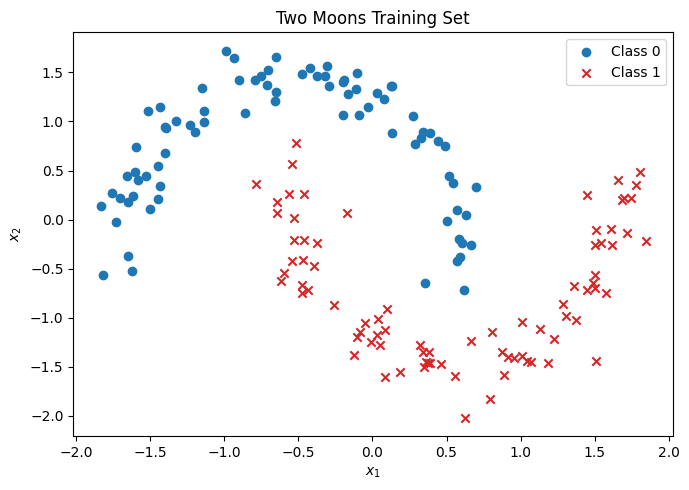

In [3]:
plot_binary_classes(
    X_train,
    y_train,
    title="Two Moons Training Set",
)

plt.show()

Unlike the dataset used in the previous notebook, these two classes cannot be separated well by a single straight line. The curved structure therefore makes Two Moons a useful example for studying nonlinear models.

Before moving on to neural networks, we will train a logistic regression model on the standardized training data. We use the model to predict the classes of the training examples and calculate the training accuracy

$$
\text{Accuracy}
=
\frac{\text{number of correct predictions}}
{\text{number of predictions}}.
$$

The accuracy tells us what proportion of the training examples is classified correctly.

To visualize the learned model, we generate a grid of points covering the feature space and predict the class of every point. The resulting background regions show where the model predicts class 0 or class 1. The dashed line between these regions is the decision boundary.

> **Note**
>
> The `predict_function` argument in the next code cell receives an anonymous function that applies the learned logistic regression model to the generated grid points. Each grid point is classified as either class 0 or class 1, producing the colored decision regions in the plot.
>
> Because logistic regression has a linear decision boundary, two points would be sufficient to draw the separating line. We nevertheless evaluate a grid of points so that the same visualization can later be reused for the nonlinear decision boundary of the neural network. The grid also allows us to display the complete decision regions rather than only the boundary itself.

Training accuracy: 88.12%


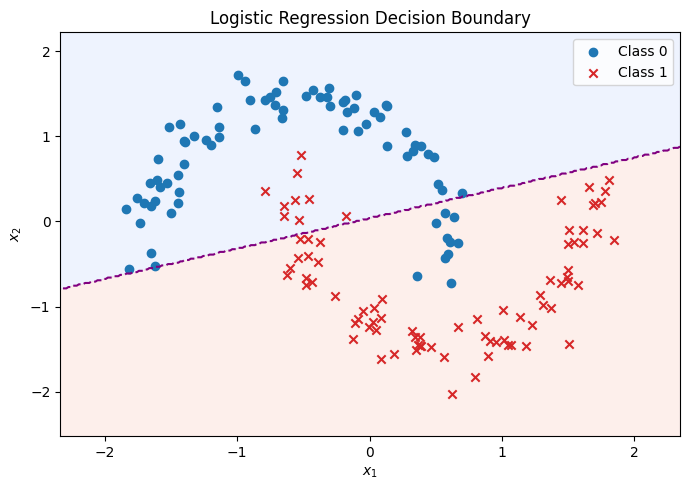

In [4]:
w_logistic, b_logistic = fit_logistic_regression(
    X_train, 
    y_train, 
    alpha=0.1, 
    iterations=10_000,
)

logistic_predictions = predict_logistic_regression(
    X_train, 
    w_logistic, 
    b_logistic,
)

logistic_accuracy = np.mean(logistic_predictions == y_train)

print(f"Training accuracy: {logistic_accuracy:.2%}")

predict_function = lambda X_grid: predict_logistic_regression(
        X_grid,
        w_logistic,
        b_logistic,
)

plot_decision_boundary(
    X_train,
    y_train,
    predict_function=predict_function,
    title="Logistic Regression Decision Boundary",
)

plt.show()

The model reaches a training accuracy of approximately $88\%$. This means that it correctly classifies most of the training examples, but it cannot fully capture the structure of the dataset.

The shaded background shows the two predicted class regions. Data points located in the region of the opposite class are misclassified. As expected from the equation

$$
w_1x_1 + w_2x_2 + b = 0,
$$

the decision boundary is a straight line. It captures the general direction of the two classes, but it cannot follow the curved shapes of the moons. Standardizing the input features changes their scale, but it does not turn a linear decision boundary into a nonlinear one.

One way to make logistic regression more flexible is to add polynomial features. For example, the original features could be extended by

$$
x_1^2,\qquad x_2^2,\qquad x_1x_2.
$$

The linear model could then operate on the transformed feature vector

$$
\begin{bmatrix}
x_1 &
x_2 &
x_1^2 &
x_2^2 &
x_1x_2
\end{bmatrix}.
$$

Although the model remains linear with respect to its parameters, these additional features allow it to represent a nonlinear decision boundary in the original feature space.

Polynomial feature engineering is a valid approach, but we have to decide in advance which transformations might be useful. As the number of original features and polynomial degrees increases, the number of possible feature combinations can also grow quickly.

A neural network takes a different approach. Its hidden units learn intermediate representations from the training data. These learned representations can make it possible for the output layer to separate classes that are not linearly separable in the original feature space.

This leads to the central question for the next chapter: How can several simple neurons be combined into a model that learns a nonlinear decision boundary?

## 3. From a Single Neuron to a Neural Network

The logistic regression model from the previous section can be viewed as a single neuron. For one input example $\mathbf{x}$, it first computes the linear combination

$$
z = \mathbf{x} \cdot \mathbf{w} + b
$$

and then applies the sigmoid activation function:

$$
a = \sigma(z).
$$

A neural network combines multiple neurons into layers. A neuron is also commonly called a **unit**. We will use these two terms interchangeably throughout this notebook.

The trainable layers in our network are **dense layers**, also called **fully connected layers**. In a dense layer, every unit receives the activations of all units in the previous layer. Each unit computes its own weighted sum and then applies an activation function.

For unit $j$ in layer $l$, these two steps are written as

$$
z_j^{[l]}
=
\mathbf{a}^{[l-1]}
\cdot
\mathbf{w}_j^{[l]}
+
b_j^{[l]}
$$

and

$$
a_j^{[l]}
=
g^{[l]}\left(z_j^{[l]}\right).
$$

The superscript $[l]$ identifies the layer, while the subscript $j$ identifies a particular unit within that layer. The function $g^{[l]}$ is the activation function used by the layer.

The following diagram shows the architecture of the neural network that we will train in this notebook.

The arrows show the flow of activation values through the network. To keep the diagram clear, the individual dense connections, weights, and biases are not shown. After the diagram, we will examine the layers and their parameters in more detail.

![Architecture of the neural network](images/neural_network_architecture.svg)

The input to our network consists of the two features $x_1$ and $x_2$. Both features are passed to every unit in the hidden layer. We can describe the input as layer 0 and write

$$
\mathbf{a}^{[0]} = \mathbf{x}.
$$

The hidden layer is layer 1 and contains four units. Each hidden unit has its own weights and bias and therefore learns a different transformation of the input features.

For example, hidden unit $j$ computes the linear combination

$$
z_j^{[1]}
=
x_1w_{1j}^{[1]}
+
x_2w_{2j}^{[1]}
+
b_j^{[1]}.
$$

The weights $w_{1j}^{[1]}$ and $w_{2j}^{[1]}$ determine how strongly the two input features contribute to this unit. The bias $b_j^{[1]}$ shifts the linear combination independently of the input values. An activation function is then applied to produce $a_j^{[1]}$.

The activations of all four hidden units are collected in the vector

$$
\mathbf{a}^{[1]}
=
\begin{bmatrix}
a_1^{[1]} &
a_2^{[1]} &
a_3^{[1]} &
a_4^{[1]}
\end{bmatrix}.
$$


The output layer is layer 2 and contains one unit. It combines the four hidden activations using its own four weights and one bias:

$$
z_1^{[2]}
=
a_1^{[1]}w_{11}^{[2]}
+
a_2^{[1]}w_{21}^{[2]}
+
a_3^{[1]}w_{31}^{[2]}
+
a_4^{[1]}w_{41}^{[2]}
+
b_1^{[2]}.
$$

The sigmoid activation function transforms this linear output into the estimated probability of the positive class:

$$
a_1^{[2]}
=
\sigma\left(z_1^{[2]}\right)
=
\hat{y}.
$$

The input layer does not contain trainable parameters. For this reason, the architecture is commonly described as a two-layer neural network: the hidden layer and the output layer are the two layers with trainable parameters.

At first glance, stacking multiple dense layers might appear sufficient to model the curved structure of the Two Moons dataset. However, stacking dense layers alone is not enough. Without a nonlinear activation function in the hidden layer, the two layer calculations would collapse into a single linear model.

To see why, consider the vectorized calculation for all $m$ training examples and assume that the hidden layer applies the identity function

$$
g^{[1]}(z)=z.
$$

The hidden activations would then be

$$
\mathbf{A}^{[1]}
=
\mathbf{X}\mathbf{W}^{[1]}
+
\mathbf{b}^{[1]}.
$$

The linear output of the second layer would become

$$
\begin{aligned}
\mathbf{Z}^{[2]}
&=
\mathbf{A}^{[1]}\mathbf{W}^{[2]}
+
\mathbf{b}^{[2]} \\
&=
\left(
\mathbf{X}\mathbf{W}^{[1]}
+
\mathbf{b}^{[1]}
\right)
\mathbf{W}^{[2]}
+
\mathbf{b}^{[2]} \\
&=
\mathbf{X}
\left(
\mathbf{W}^{[1]}\mathbf{W}^{[2]}
\right)
+
\left(
\mathbf{b}^{[1]}\mathbf{W}^{[2]}
+
\mathbf{b}^{[2]}
\right).
\end{aligned}
$$

We can combine the two weight matrices and the two bias terms into

$$
\mathbf{W}_{\text{effective}}
=
\mathbf{W}^{[1]}\mathbf{W}^{[2]}
$$

and

$$
\mathbf{b}_{\text{effective}}
=
\mathbf{b}^{[1]}\mathbf{W}^{[2]}
+
\mathbf{b}^{[2]}.
$$

The complete calculation would therefore have the same form as a single linear model:

$$
\mathbf{Z}^{[2]}
=
\mathbf{X}\mathbf{W}_{\text{effective}}
+
\mathbf{b}_{\text{effective}}.
$$

Applying sigmoid at the output would transform these values into probabilities, but the decision boundary would still be linear, just as it was for logistic regression.

To learn a nonlinear decision boundary, the hidden layer must therefore apply a nonlinear activation function. In the next chapter, we will examine the activation functions used by the hidden and output layers.

> **Work in Progress**
>
> This notebook is currently under development. The remaining chapters will be added step by step.